In [ ]:
import networkx as nx

# Create an empty undirected graph
G = nx.Graph()

# Add your edges and weights
edges = [
    ('Entrance', 'S6.05', 1),
    ('S6.01', 'S6.02', 2),
    ('S6.01', 'S6.06', 2),
    ('S6.02', 'S6.03', 3),
    ('S6.03', 'S6.05', 1),
    ('S6.05', 'S6.06', 2)
]

G.add_weighted_edges_from(edges)

In [ ]:
# This creates a new graph that is the "skeleton" of G
MST = nx.minimum_spanning_tree(G)

print("Edges in MST:", MST.edges(data=True))

Edges in MST: [('Entrance', 'S6.05', {'weight': 1}), ('S6.05', 'S6.03', {'weight': 1}), ('S6.05', 'S6.06', {'weight': 2}), ('S6.01', 'S6.02', {'weight': 2}), ('S6.01', 'S6.06', {'weight': 2})]


In [ ]:
# Generate the sequence of nodes
route = list(nx.dfs_preorder_nodes(MST, source='Entrance'))

print("Delivery Route Sequence:", " -> ".join(route))
# Expected output: Entrance -> S6.05 -> S6.03 -> S6.06 -> S6.01 -> S6.02

Delivery Route Sequence: Entrance -> S6.05 -> S6.03 -> S6.06 -> S6.01 -> S6.02


In [ ]:
total_cost = 0
for i in range(len(route) - 1):
    u, v = route[i], route[i+1]
    # We find the weight of the shortest path between these two nodes in our ORIGINAL graph G
    total_cost += nx.shortest_path_length(G, u, v, weight='weight')

print(f"Total Travel Cost: {total_cost}")

Total Travel Cost: 9


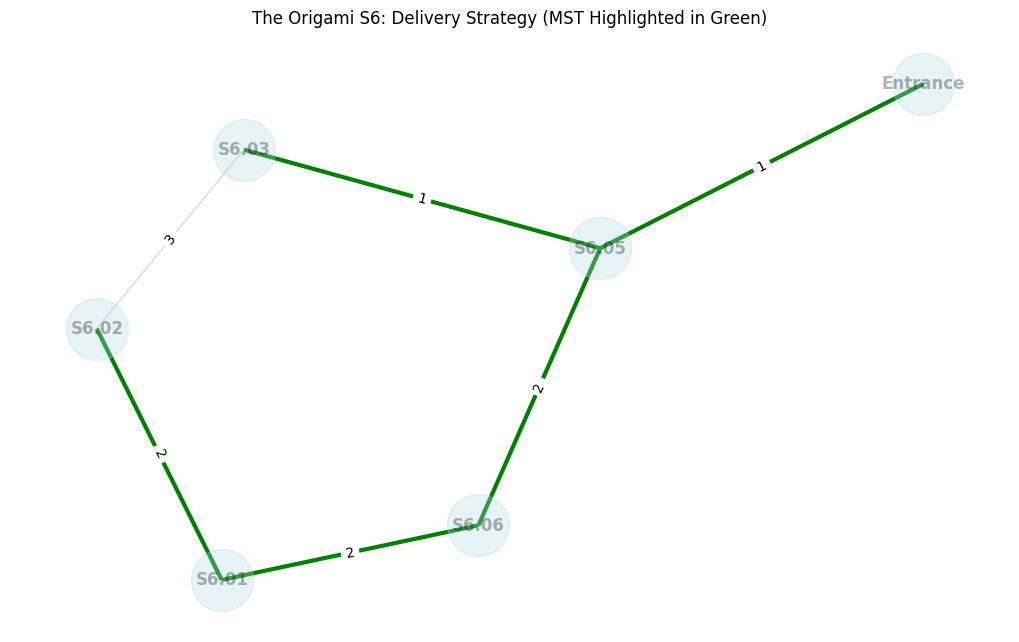

Delivery Sequence: Entrance -> S6.05 -> S6.03 -> S6.06 -> S6.01 -> S6.02


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Setup the Graph
G = nx.Graph()
edges = [
    ('Entrance', 'S6.05', 1), ('S6.01', 'S6.02', 2),
    ('S6.01', 'S6.06', 2), ('S6.02', 'S6.03', 3),
    ('S6.03', 'S6.05', 1), ('S6.05', 'S6.06', 2)
]
G.add_weighted_edges_from(edges)

# 2. Calculate MST and Route
mst = nx.minimum_spanning_tree(G)
route = list(nx.dfs_preorder_nodes(mst, source='Entrance'))

# 3. Layout and Drawing
pos = nx.spring_layout(G, seed=42)  # Positions nodes in a 2D space
plt.figure(figsize=(10, 6))

# Draw everything first (faded)
nx.draw(G, pos, with_labels=True, node_color='lightblue',
        node_size=2000, font_weight='bold', edge_color='gray', alpha=0.3)

# Highlight MST edges (Green)
nx.draw_networkx_edges(G, pos, edgelist=mst.edges(), edge_color='green', width=3)

# Draw Edge Labels (Weights)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("The Origami S6: Delivery Strategy (MST Highlighted in Green)")
plt.show()

print(f"Delivery Sequence: {' -> '.join(route)}")

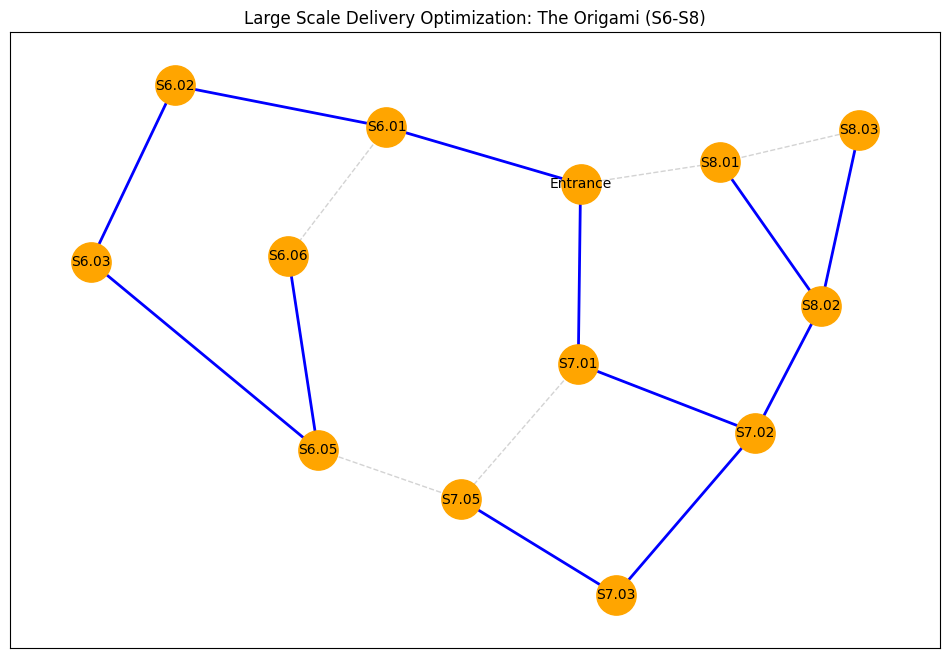

📦 Optimized Route: Entrance -> S6.01 -> S6.02 -> S6.03 -> S6.05 -> S6.06 -> S7.01 -> S7.02 -> S7.03 -> S7.05 -> S8.02 -> S8.03 -> S8.01


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Create a larger graph
G = nx.Graph()

# Edges: (From, To, Weight)
large_edges = [
    # Entrance to Clusters
    ('Entrance', 'S6.01', 4), ('Entrance', 'S7.01', 5), ('Entrance', 'S8.01', 8),
    # Cluster S6
    ('S6.01', 'S6.02', 2), ('S6.02', 'S6.03', 2), ('S6.03', 'S6.05', 1),
    ('S6.05', 'S6.06', 2), ('S6.06', 'S6.01', 3),
    # Cluster S7
    ('S7.01', 'S7.02', 2), ('S7.02', 'S7.03', 2), ('S7.03', 'S7.05', 3),
    ('S7.05', 'S7.01', 4),
    # Cluster S8
    ('S8.01', 'S8.02', 3), ('S8.02', 'S8.03', 2), ('S8.03', 'S8.01', 4),
    # Inter-Cluster "Bridges"
    ('S6.05', 'S7.05', 6), ('S7.02', 'S8.02', 7)
]

G.add_weighted_edges_from(large_edges)

# 2. Compute MST and Route
mst = nx.minimum_spanning_tree(G)
route = list(nx.dfs_preorder_nodes(mst, source='Entrance'))

# 3. Visualization
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=10) # Constant layout

# Draw all roads (faded)
nx.draw_networkx_edges(G, pos, edge_color='lightgray', style='dashed')
# Draw MST (The Strategy)
nx.draw_networkx_edges(G, pos, edgelist=mst.edges(), edge_color='blue', width=2)
# Draw Nodes
nx.draw_networkx_nodes(G, pos, node_color='orange', node_size=800)
nx.draw_networkx_labels(G, pos, font_size=10)

plt.title("Large Scale Delivery Optimization: The Origami (S6-S8)")
plt.show()

print(f"📦 Optimized Route: {' -> '.join(route)}")